<a href="https://colab.research.google.com/github/RandomArnab/dl-llm-from-scratch/blob/main/RNN/character_rnn/rnn_classifying_names.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

torch.set_default_device(device)
print(f"Using device : {torch.get_default_device()}")

Using device : cpu


In [2]:
# Data Prep.

import string
import unicodedata

allowed_characters = string.ascii_letters + " .,;'" + "_"
print(allowed_characters)
n_letters = len(allowed_characters)
print(n_letters)

def unicode_to_ascii(s: str) -> str:
    """Decomposes Unicode characters and strips accent marks."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

unicode_text = "Ślusàrski"

ascii_text = unicode_to_ascii(unicode_text)
print(f"ASCII Text: {ascii_text}")

abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,;'_
58
ASCII Text: Slusarski


In [3]:
# Turning names into tensors.

def letter_to_index(letter):
    if letter not in allowed_characters:
        return allowed_characters.find('_')
    else:
        return allowed_characters.find(letter)

def line_to_tensor(line):
    tensor = torch.zeros(len(line),1,n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letter_to_index(letter)] = 1
    return tensor

In [7]:
line='Arnab'
tensor = torch.zeros(len(line), 1, n_letters)
print(letter_to_index(line[0]))
print('='*150)
print(line_to_tensor(line))

26
tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0.

In [8]:
from io import open
import glob
import os
import time
import torch
from tqdm import tqdm_notebook
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

class Names_Dataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.load_time = time.localtime()
        labels_set = set()

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in tqdm_notebook(text_files):
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(line_to_tensor(name))
                self.labels.append(label)

        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]
        return data_item, data_label, data_tensor, label_tensor

In [13]:
all_data = Names_Dataset('/content/languages/')
print(f"loaded {len(all_data)} items of data")
print(f"example = {all_data[1]}")

  0%|          | 0/18 [00:00<?, ?it/s]

loaded 20074 items of data
example = ('Ahearn', 'Irish', tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.

In [14]:
train_set, test_set = torch.utils.data.random_split(all_data, [.7, 0.3],
                                                    generator = torch.Generator().manual_seed(2026))
print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 14052, validation examples = 6022


In [15]:
import torch.nn as nn
import torch.nn.functional as F

class Char_RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Char_RNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim = 1)

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        final_output = self.softmax(output)
        return final_output

In [16]:
input_size = n_letters
hidden_size = 128
output_size = len(all_data.labels_uniq)
line_tensor = line_to_tensor('Harry')

rnn = nn.RNN(input_size, hidden_size)
h20 = nn.Linear(hidden_size, output_size)
softmax = nn.LogSoftmax(dim = 1)

rnn_out, hidden = rnn(line_tensor)
output = h20(hidden[0])
final_output = softmax(output)

top_n, top_i = final_output.topk(1)
label_i = top_i[0].item()

print(line_tensor)
print('='*150)
print(rnn_out)
print('='*150)
print(hidden)
print('='*150)
print(output)
print('='*150)
print(final_output)
print('='*150)
print(final_output.topk(1))
print('='*150)
print(top_n)
print('='*150)
print(top_i)
print('='*150)
print(label_i)
print('='*150)
print(all_data.labels_uniq[label_i])

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0

In [123]:
n_hidden = 128
rnn = Char_RNN(n_letters, n_hidden, len(all_data.labels_uniq))
print(rnn)

Char_RNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [40]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = line_to_tensor('Fernando')
output = rnn.forward(input)
label_from_output(output, all_data.labels_uniq)

('Russian', 16)

In [41]:
import random
import numpy as np

def train(rnn, training_data, n_epoch=10, n_batch_size=64, report_every=50,
          learning_rate=0.2, criterion = nn.NLLLoss()):

    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start_time = time.time()
    for iter in tqdm_notebook(range(1, n_epoch+1)):
        rnn.zero_grad()

        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches)// n_batch_size)

        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch:
                text, label, text_tensor, label_tensor = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            batch_loss.backward()
            nn.utils.clip_grad_norm(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss/len(batches))

        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t average batch loss = {all_losses[-1]}")
        current_loss = 0
    return all_losses

In [42]:
rnn.parameters()

<generator object Module.parameters at 0x787aabbb04a0>

In [43]:
n_hidden = 128
start_time = time.time()
rnn = Char_RNN(n_letters, n_hidden, len(all_data.labels_uniq))
all_losses = train(rnn, train_set, n_epoch=27, learning_rate=0.15, report_every=5)
end_time = time.time()
print(f"training took {end_time - start_time}s")

  0%|          | 0/27 [00:00<?, ?it/s]

5 (19%): 	 average batch loss = 0.9150956598235132
10 (37%): 	 average batch loss = 0.7360656983231845
15 (56%): 	 average batch loss = 0.6054229259386287
20 (74%): 	 average batch loss = 0.5103910814493131
25 (93%): 	 average batch loss = 0.4280890533808537
training took 624.129834651947s


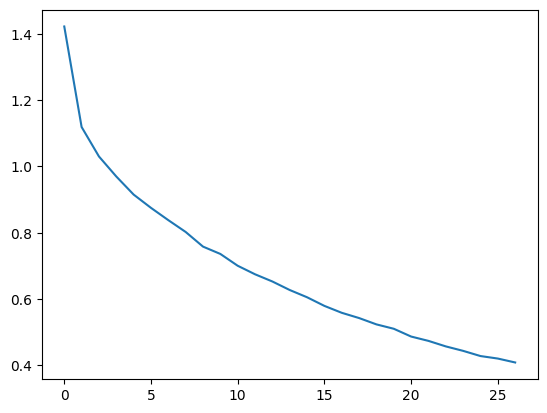

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

In [49]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    rnn.eval()
    with torch.no_grad():
        for idx in range(len(testing_data)):
            text, label, text_tensor, label_tensor = testing_data[idx]
            output = rnn.forward(text_tensor)
            guess, guess_idx = label_from_output(output, classes)
            label_idx = classes.index(label)
            confusion[label_idx][guess_idx] += 1

    for idx in range(len(classes)):
        denominator = confusion[idx].sum()
        if denominator>0:
            confusion[idx] /= denominator

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy())
    fig.colorbar(cax)

    ax.set_xticks(np.arange(len(classes)), labels = classes, rotation = 90)
    ax.set_yticks(np.arange(len(classes)), labels = classes)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

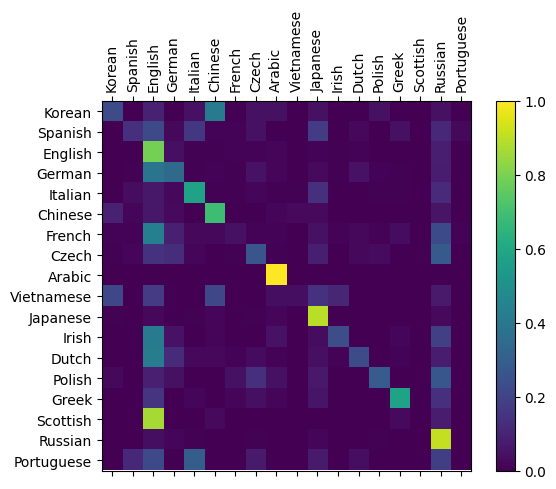

In [50]:
evaluate(rnn, test_set, classes = all_data.labels_uniq)